# Document Extraction with Docling

Docling is an open-source document parsing library by IBM that converts PDFs, Word documents, PowerPoint files, HTML, images, and more into structured, AI-ready formats.

**Supported formats:** PDF, DOCX, PPTX, XLSX, HTML, Images (PNG/JPG), AsciiDoc, Markdown

## 1. Installation

In [2]:
# # Install docling and optional dependencies
# %pip install docling

# %pip install docling-core

## 2. Imports & Setup

In [1]:
import json
import time
from pathlib import Path

from docling.document_converter import DocumentConverter
from docling.datamodel.base_models import InputFormat
from docling.datamodel.pipeline_options import (
    PdfPipelineOptions,
    TesseractCliOcrOptions,
)
from docling.document_converter import (
    DocumentConverter,
    PdfFormatOption,
)

print("Docling imported successfully!")

Docling imported successfully!


## 3. Basic Document Conversion (URL or File Path)

Convert any document — PDF, DOCX, HTML — with a single call.

In [4]:
# Initialize the converter
converter = DocumentConverter()

# ----- Option A: convert from a URL -----
source_url = "https://arxiv.org/pdf/2408.09869"  # Docling paper itself

start = time.time()
result = converter.convert(source_url)
elapsed = time.time() - start

doc = result.document
print(f"Converted in {elapsed:.1f}s")
print(f"Number of pages : {len(doc.pages) if hasattr(doc, 'pages') else 'N/A'}")
print(f"Document type   : {type(doc).__name__}")

[INFO] 2026-06-16 11:55:20,338 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-06-16 11:55:20,343 [RapidOCR] download_file.py:60: File exists and is valid: /opt/anaconda3/lib/python3.13/site-packages/rapidocr/models/ch_PP-OCRv4_det_mobile.onnx
[INFO] 2026-06-16 11:55:20,343 [RapidOCR] main.py:65: Using /opt/anaconda3/lib/python3.13/site-packages/rapidocr/models/ch_PP-OCRv4_det_mobile.onnx
[INFO] 2026-06-16 11:55:20,375 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-06-16 11:55:20,378 [RapidOCR] download_file.py:60: File exists and is valid: /opt/anaconda3/lib/python3.13/site-packages/rapidocr/models/ch_ppocr_mobile_v2.0_cls_mobile.onnx
[INFO] 2026-06-16 11:55:20,379 [RapidOCR] main.py:65: Using /opt/anaconda3/lib/python3.13/site-packages/rapidocr/models/ch_ppocr_mobile_v2.0_cls_mobile.onnx
[INFO] 2026-06-16 11:55:20,410 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-06-16 11:55:20,422 [RapidOCR] download_file.py:60: File exists an

Loading weights:   0%|          | 0/770 [00:00<?, ?it/s]

Converted in 72.3s
Number of pages : 9
Document type   : DoclingDocument


In [5]:
doc

DoclingDocument(schema_name='DoclingDocument', version='1.10.0', name='2408', origin=DocumentOrigin(mimetype='application/pdf', binary_hash=11465328351749295394, filename='2408.09869', uri=None), furniture=GroupItem(self_ref='#/furniture', parent=None, children=[], content_layer=<ContentLayer.FURNITURE: 'furniture'>, meta=None, name='_root_', label=<GroupLabel.UNSPECIFIED: 'unspecified'>), body=GroupItem(self_ref='#/body', parent=None, children=[RefItem(cref='#/texts/0'), RefItem(cref='#/pictures/0'), RefItem(cref='#/texts/1'), RefItem(cref='#/texts/2'), RefItem(cref='#/texts/3'), RefItem(cref='#/texts/4'), RefItem(cref='#/texts/5'), RefItem(cref='#/texts/6'), RefItem(cref='#/texts/7'), RefItem(cref='#/texts/8'), RefItem(cref='#/texts/9'), RefItem(cref='#/texts/10'), RefItem(cref='#/texts/11'), RefItem(cref='#/texts/12'), RefItem(cref='#/groups/0'), RefItem(cref='#/texts/20'), RefItem(cref='#/texts/21'), RefItem(cref='#/texts/22'), RefItem(cref='#/texts/23'), RefItem(cref='#/texts/24')

In [ ]:
# ----- Option B: convert a local file -----
# Uncomment and set your file path
# local_path = Path("./sample.pdf")
# result = converter.convert(local_path)
# doc = result.document

## 4. Export to Markdown

In [6]:
# Uncomment and set your file path
# local_path = Path("./sample.pdf")
# result = converter.convert(local_path)
# doc = result.document
markdown_output = doc.export_to_markdown()

# Preview first 2000 characters
print(markdown_output[:2000])
print("\n... (truncated)")

# Save to file
Path("output.md").write_text(markdown_output, encoding="utf-8")
print("\nSaved to output.md")

<!-- image -->

## Docling Technical Report

## Version 1.0

Christoph Auer Maksym Lysak Ahmed Nassar Michele Dolfi Nikolaos Livathinos Panos Vagenas Cesar Berrospi Ramis Matteo Omenetti Fabian Lindlbauer Kasper Dinkla Lokesh Mishra Yusik Kim Shubham Gupta Rafael Teixeira de Lima Valery Weber Lucas Morin Ingmar Meijer Viktor Kuropiatnyk Peter W. J. Staar

AI4K Group, IBM Research R¨ uschlikon, Switzerland

## Abstract

This technical report introduces Docling , an easy to use, self-contained, MITlicensed open-source package for PDF document conversion. It is powered by state-of-the-art specialized AI models for layout analysis (DocLayNet) and table structure recognition (TableFormer), and runs efficiently on commodity hardware in a small resource budget. The code interface allows for easy extensibility and addition of new features and models.

## 1 Introduction

Converting PDF documents back into a machine-processable format has been a major challenge for decades due to their huge vari

## 5. Export to JSON (structured)

In [7]:
doc_dict = doc.export_to_dict()

# Save full JSON
with open("output.json", "w", encoding="utf-8") as f:
    json.dump(doc_dict, f, indent=2, ensure_ascii=False)

# Preview top-level keys
print("Top-level keys in JSON output:")
for key in doc_dict.keys():
    print(f"  - {key}")

print("\nSaved to output.json")

Top-level keys in JSON output:
  - schema_name
  - version
  - name
  - origin
  - furniture
  - body
  - groups
  - texts
  - pictures
  - tables
  - key_value_items
  - form_items
  - pages

Saved to output.json


## 6. Table Extraction

In [8]:
import pandas as pd
from docling_core.types.doc import TableItem

tables = [item for item, _ in doc.iterate_items() if isinstance(item, TableItem)]
print(f"Found {len(tables)} table(s) in the document.\n")

for idx, table in enumerate(tables):
    print(f"--- Table {idx + 1} ---")
    try:
        df = table.export_to_dataframe()
        print(df.to_string(index=False))
    except Exception as e:
        print(f"Could not render as DataFrame: {e}")
        # Fall back to markdown
        print(table.export_to_markdown())
    print()

Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.
Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.
Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.


Found 3 table(s) in the document.

--- Table 1 ---
                   CPU. Thread budget. native backend.TTS native backend.Pages/s native backend.Mem pypdfium backend.TTS pypdfium backend.Pages/s pypdfium backend.Mem
Apple M3 Max (16 cores)           4 16        177 s 167 s              1.27 1.34            6.20 GB           103 s 92 s                2.18 2.45              2.56 GB
  Intel(R) Xeon E5-2690           4 16        375 s 244 s              0.60 0.92            6.16 GB          239 s 143 s                0.94 1.57              2.42 GB

--- Table 2 ---
                                                                                                                                                                         human                                                                                                          MRCNN R50 R101                                                  FRCNN R101                                                   YOLO v5x6
Caption Footnote

## 7. Iterate Over Document Elements

Access headings, paragraphs, lists, figures, tables individually.

In [9]:
from docling_core.types.doc import (
    TextItem,
    SectionHeaderItem,
    ListItem,
    PictureItem,
    TableItem,
)

element_counts = {}

for item, _ in doc.iterate_items():
    label = type(item).__name__
    element_counts[label] = element_counts.get(label, 0) + 1

print("Element type counts:")
for name, count in sorted(element_counts.items(), key=lambda x: -x[1]):
    print(f"  {name:30s}: {count}")

Element type counts:
  TextItem                      : 70
  ListItem                      : 23
  SectionHeaderItem             : 22
  PictureItem                   : 5
  TableItem                     : 3
  CodeItem                      : 1


In [10]:
# Print all section headings
print("Section Headings:\n" + "-" * 40)
for item, _ in doc.iterate_items():
    if isinstance(item, SectionHeaderItem):
        indent = "  " * (item.level - 1) if hasattr(item, "level") else ""
        print(f"{indent}{item.text}")

Section Headings:
----------------------------------------
Docling Technical Report
Version 1.0
Abstract
1 Introduction
2 Getting Started
3 Processing pipeline
3.1 PDF backends
3.2 AI models
Layout Analysis Model
Table Structure Recognition
OCR
3.3 Assembly
3.4 Extensibility
4 Performance
5 Applications
6 Future work and contributions
References
Appendix
5 EXPERIMENTS
Baselines for Object Detection
5EXPERIMENTS
BaselinesforObjectDetection


## 8. PDF-Specific Options: OCR, Table Detection

In [11]:
# Enable OCR + advanced table detection for scanned PDFs
pipeline_options = PdfPipelineOptions()
pipeline_options.do_ocr = True                # run OCR on image-based PDFs
pipeline_options.do_table_structure = True    # detect and parse table structure
pipeline_options.table_structure_options.do_cell_matching = True

ocr_converter = DocumentConverter(
    format_options={
        InputFormat.PDF: PdfFormatOption(pipeline_options=pipeline_options)
    }
)

print("OCR-enabled converter ready.")
print("Use: result = ocr_converter.convert('path/to/scanned.pdf')")

OCR-enabled converter ready.
Use: result = ocr_converter.convert('path/to/scanned.pdf')


## 9. Batch Conversion (Multiple Files)

In [ ]:
# Convert multiple documents in one call
sources = [
    "https://arxiv.org/pdf/2408.09869",
    # Add more URLs or local paths here
    # Path("./doc1.pdf"),
    # Path("./doc2.docx"),
]

batch_converter = DocumentConverter()
results = list(batch_converter.convert_all(sources))

print(f"Converted {len(results)} document(s)")
for i, res in enumerate(results):
    md = res.document.export_to_markdown()
    print(f"  Doc {i+1}: {len(md)} chars of markdown")

## 10. Export to HTML

In [12]:
# Export to HTML
html_output = doc.export_to_html()
Path("output.html").write_text(html_output, encoding="utf-8")

print(f"HTML saved ({len(html_output)} bytes) → output.html")
print("\nHTML preview (first 500 chars):")
print(html_output[:500])

HTML saved (39369 bytes) → output.html

HTML preview (first 500 chars):
<!DOCTYPE html>
<html>
<head>
<meta charset="UTF-8"/>
<title>2408</title>
<meta name="generator" content="Docling HTML Serializer"/>
<style>
    html {
        background-color: #f5f5f5;
        font-family: Arial, sans-serif;
        line-height: 1.6;
    }
    body {
        max-width: 800px;
        margin: 0 auto;
        padding: 2rem;
        background-color: white;
        box-shadow: 0 0 10px rgba(0,0,0,0.1);
    }
    h1, h2, h3, h4, h5, h6 {
        color: #333;
        margin-top: 1.


## 11. Chunking for RAG / LLM Pipelines

Split the document into semantically meaningful chunks, ready for embedding.

In [13]:
from docling.chunking import HybridChunker

chunker = HybridChunker(tokenizer="BAAI/bge-small-en-v1.5")  # or any HF tokenizer
chunks = list(chunker.chunk(dl_doc=doc))

print(f"Total chunks: {len(chunks)}")
print("\n--- First 3 Chunks ---")
for i, chunk in enumerate(chunks[:3]):
    print(f"\n[Chunk {i+1}] ({len(chunk.text)} chars)")
    print(chunk.text[:300])
    if chunk.meta.headings:
        print(f"  Headings: {chunk.meta.headings}")

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (702 > 512). Running this sequence through the model will result in indexing errors


Total chunks: 30

--- First 3 Chunks ---

[Chunk 1] (346 chars)
Christoph Auer Maksym Lysak Ahmed Nassar Michele Dolfi Nikolaos Livathinos Panos Vagenas Cesar Berrospi Ramis Matteo Omenetti Fabian Lindlbauer Kasper Dinkla Lokesh Mishra Yusik Kim Shubham Gupta Rafael Teixeira de Lima Valery Weber Lucas Morin Ingmar Meijer Viktor Kuropiatnyk Peter W. J. Staar
AI4K
  Headings: ['Version 1.0']

[Chunk 2] (431 chars)
This technical report introduces Docling , an easy to use, self-contained, MITlicensed open-source package for PDF document conversion. It is powered by state-of-the-art specialized AI models for layout analysis (DocLayNet) and table structure recognition (TableFormer), and runs efficiently on commo
  Headings: ['Abstract']

[Chunk 3] (1848 chars)
Converting PDF documents back into a machine-processable format has been a major challenge for decades due to their huge variability in formats, weak standardization and printing-optimized characteristic, which discards most structura

## 12. Extract Metadata

In [14]:
meta = doc.origin if hasattr(doc, "origin") else None
if meta:
    print("Document origin metadata:")
    print(f"  filename  : {meta.filename}")
    print(f"  mimetype  : {meta.mimetype}")
    print(f"  binary hash: {meta.binary_hash}")

if hasattr(doc, "description") and doc.description:
    d = doc.description
    print("\nDocument description:")
    print(f"  title     : {d.title}")
    print(f"  authors   : {d.authors}")
    print(f"  language  : {d.language}")
    print(f"  keywords  : {d.keywords}")

Document origin metadata:
  filename  : 2408.09869
  mimetype  : application/pdf
  binary hash: 11465328351749295394


## 13. Image / Figure Extraction

In [15]:
from docling_core.types.doc import PictureItem
from IPython.display import display, Image as IPImage

figures = [item for item, _ in doc.iterate_items() if isinstance(item, PictureItem)]
print(f"Found {len(figures)} figure(s)")

# Save and display the first few figures
for idx, fig in enumerate(figures[:3]):
    img_path = Path(f"figure_{idx+1}.png")
    with img_path.open("wb") as f:
        fig.image.pil_image.save(f, format="PNG")
    print(f"Saved {img_path}")
    display(IPImage(filename=str(img_path), width=400))

Found 5 figure(s)


AttributeError: 'NoneType' object has no attribute 'pil_image'

## Summary

| Feature | Method |
|---|---|
| Convert any document | `DocumentConverter().convert(path_or_url)` |
| Export Markdown | `doc.export_to_markdown()` |
| Export JSON | `doc.export_to_dict()` |
| Export HTML | `doc.export_to_html()` |
| Extract tables | `iterate_items()` → filter `TableItem` |
| Extract images | `iterate_items()` → filter `PictureItem` |
| Chunk for RAG | `HybridChunker().chunk(doc)` |
| OCR scanned PDFs | `PdfPipelineOptions(do_ocr=True)` |
| Batch convert | `converter.convert_all([...])` |

In [16]:
# Uncomment and set your file path
local_path = Path("R_Healthbeat_Magazine_Single_pages.pdf")
result = converter.convert(local_path)
doc = result.document

In [19]:
doc_json = doc.to_json()

AttributeError: 'DoclingDocument' object has no attribute 'to_json'

[INFO] 2026-06-16 12:04:33,092 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-06-16 12:04:33,097 [RapidOCR] download_file.py:60: File exists and is valid: /opt/anaconda3/lib/python3.13/site-packages/rapidocr/models/ch_PP-OCRv4_det_mobile.onnx
[INFO] 2026-06-16 12:04:33,097 [RapidOCR] main.py:65: Using /opt/anaconda3/lib/python3.13/site-packages/rapidocr/models/ch_PP-OCRv4_det_mobile.onnx
[INFO] 2026-06-16 12:04:33,123 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-06-16 12:04:33,125 [RapidOCR] download_file.py:60: File exists and is valid: /opt/anaconda3/lib/python3.13/site-packages/rapidocr/models/ch_ppocr_mobile_v2.0_cls_mobile.onnx
[INFO] 2026-06-16 12:04:33,125 [RapidOCR] main.py:65: Using /opt/anaconda3/lib/python3.13/site-packages/rapidocr/models/ch_ppocr_mobile_v2.0_cls_mobile.onnx
[INFO] 2026-06-16 12:04:33,140 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-06-16 12:04:33,146 [RapidOCR] download_file.py:60: File exists an

Loading weights:   0%|          | 0/770 [00:00<?, ?it/s]

Found 5 figure(s)
Saved figure_1.png


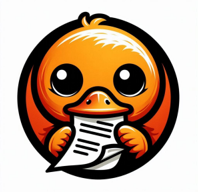

Saved figure_2.png


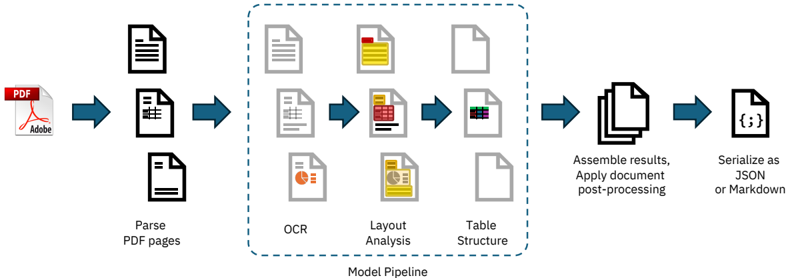

Saved figure_3.png


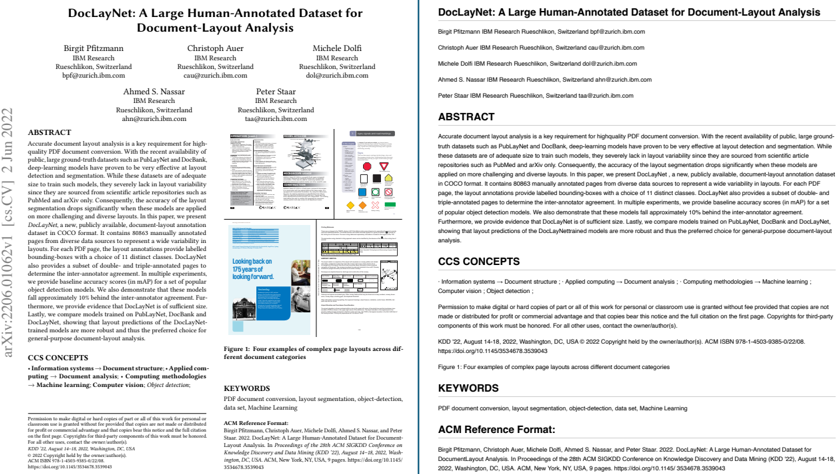

In [18]:

from docling_core.types.doc import PictureItem
from docling.datamodel.pipeline_options import PdfPipelineOptions
from docling.datamodel.base_models import InputFormat
from docling.document_converter import DocumentConverter, PdfFormatOption
from IPython.display import display, Image as IPImage

# Re-convert with image extraction enabled
pipeline_options = PdfPipelineOptions()
pipeline_options.generate_picture_images = True   # populate fig.image
pipeline_options.images_scale = 2.0               # higher = better resolution

img_converter = DocumentConverter(
    format_options={
        InputFormat.PDF: PdfFormatOption(pipeline_options=pipeline_options)
    }
)

result_with_images = img_converter.convert(source_url)
doc_with_images = result_with_images.document

figures = [item for item, _ in doc_with_images.iterate_items() if isinstance(item, PictureItem)]
print(f"Found {len(figures)} figure(s)")

for idx, fig in enumerate(figures[:3]):
    if fig.image is None or fig.image.pil_image is None:
        print(f"Figure {idx+1}: no image data available, skipping.")
        continue
    img_path = Path(f"figure_{idx+1}.png")
    with img_path.open("wb") as f:
        fig.image.pil_image.save(f, format="PNG")
    print(f"Saved {img_path}")
    display(IPImage(filename=str(img_path), width=400))

In [21]:
# Export to HTML
html_output = doc.export_to_html()
Path("output2.html").write_text(html_output, encoding="utf-8")

print(f"HTML saved ({len(html_output)} bytes) → output.html")
print("\nHTML preview (first 500 chars):")
print(html_output[:500])

HTML saved (71709 bytes) → output.html

HTML preview (first 500 chars):
<!DOCTYPE html>
<html>
<head>
<meta charset="UTF-8"/>
<title>R_Healthbeat_Magazine_Single_pages</title>
<meta name="generator" content="Docling HTML Serializer"/>
<style>
    html {
        background-color: #f5f5f5;
        font-family: Arial, sans-serif;
        line-height: 1.6;
    }
    body {
        max-width: 800px;
        margin: 0 auto;
        padding: 2rem;
        background-color: white;
        box-shadow: 0 0 10px rgba(0,0,0,0.1);
    }
    h1, h2, h3, h4, h5, h6 {
        color


In [22]:
from docling_core.types.doc import (
    TextItem,
    SectionHeaderItem,
    ListItem,
    PictureItem,
    TableItem,
)

element_counts = {}

for item, _ in doc.iterate_items():
    label = type(item).__name__
    element_counts[label] = element_counts.get(label, 0) + 1

print("Element type counts:")
for name, count in sorted(element_counts.items(), key=lambda x: -x[1]):
    print(f"  {name:30s}: {count}")

Element type counts:
  TextItem                      : 235
  SectionHeaderItem             : 107
  PictureItem                   : 99
  ListItem                      : 72


In [23]:
# Uncomment and set your file path
local_path = Path("datasets/notes_to_investment_proof_submission.pdf")
result = converter.convert(local_path)
doc1 = result.document
markdown_output1 = doc1.export_to_markdown()

# Preview first 2000 characters
print(markdown_output1[:2000])
print("\n... (truncated)")

# Save to file
Path("output1.md").write_text(markdown_output1, encoding="utf-8")
print("\nSaved to output1.md")

1. New Tax Regime
2. Rent paid (HRA exemption)
3. Loss from House property (Interest paid on housing loan) &amp; Income from House Property
4. Loss from house property (Interest on Housing Loan) - Additional Deduction (Section 80EE)
5. Loss from house property (Interest on Housing Loan) - Additional Deduction (Section 80EEA)
6. Salary from Previous employment
7. Medical Insurance Premium - (Section 80D) - Self / Spouse / Children
8. Medical Treatment/Contribution to fund for maintenance of handicapped dependent -(Sec 80DD)
9. Medical treatment in case of specified ailments or disease (Sec 80DDB)
10. Deduction in respect of Payment of Interest taken for higher education (Section 80E)
11. Deduction in respect of totally blind/physically handicapped employee-(Sec 80 U)
12. Section 80EEB - Tax deduction on Loan for Purchase of Electric Vehicles
13. Contribution to Pension Schemes (Ex: - Pension Fund)
14. Life Insurance Premium
15. Public Provident Fund
16. National Saving Certificates (NSC

In [24]:
# Uncomment and set your file path
local_path = Path("datasets/User Guide for Investment Proof (Stohrm Scan copy submission).pdf")
result = converter.convert(local_path)
doc12 = result.document
markdown_output12 = doc12.export_to_markdown()

# Preview first 2000 characters
print(markdown_output12[:2000])
print("\n... (truncated)")

# Save to file
Path("output12.md").write_text(markdown_output12, encoding="utf-8")
print("\nSaved to output12.md")


[WARNING] 2026-06-17 01:29:51,788 [RapidOCR] main.py:132: The text detection result is empty
RapidOCR returned empty result!
RapidOCR returned empty result!
RapidOCR returned empty result!


<!-- image -->

User Guide for EPSF (Employee) - Standard Document

<!-- image -->

## Ascent Consulting Services Pvt. Ltd.

## User Guide for Employee Proof Submission

## Standard Document

(Employee Perspective)

Powered  by

<!-- image -->

<!-- image -->

## Copyrights

Copyright © Ascent Consulting Services Private Limited. All rights reserved. The following are trademarks of AscentHR:

In addition, AscentHR images, logos, headers, icons not to be used in any manner by anyone without prior permission from AscentHR. All other trademarks not owned by AscentHR are the property of their respective owners.

## Disclaimer

This document might include technical inaccuracies and is subject to correction and other revision without notice. It asserts that no warranties or representations are given in rel ation to the legal information and it seeks to exclude any liabilities that may arise out of the use or misuse of the information. AscentHR is not responsible for, and expressly disclaims 

In [25]:
from docling_core.types.doc import ImageRefMode

# ── Option A: EMBEDDED (base64 inside the .md — one self-contained file) ──────
md_embedded = doc_with_images.export_to_markdown(image_mode=ImageRefMode.EMBEDDED)
Path("output_with_images_embedded.md").write_text(md_embedded, encoding="utf-8")
print(f"Embedded markdown saved ({len(md_embedded):,} bytes) → output_with_images_embedded.md")

# ── Option B: REFERENCED (images saved as separate PNGs, markdown links them) ─
output_dir = Path("output_referenced")
doc_with_images.save_as_markdown(output_dir, image_mode=ImageRefMode.REFERENCED)
print(f"Referenced markdown saved → {output_dir}/")
print("  Images are in:", list((output_dir).glob("**/*.png"))[:5])

Embedded markdown saved (760,966 bytes) → output_with_images_embedded.md
Referenced markdown saved → output_referenced/
  Images are in: []


In [3]:
# Uncomment and set your file path
local_path = Path("datasets/Generative AI System Design Interview{Ali Aminian_ Hao Sheng}(2024 November 16, ByteByteGo, Inc){111104690} libgen.li.pdf")
# Initialize the converter
converter = DocumentConverter()
result = converter.convert(local_path)
doc123 = result.document
markdown_output12 = doc123.export_to_markdown()

# Preview first 2000 characters
print(markdown_output12[:2000])
print("\n... (truncated)")

# Save to file
Path("output12.md").write_text(markdown_output12, encoding="utf-8")
print("\nSaved to output123.md")


[INFO] 2026-06-19 02:16:50,190 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-06-19 02:16:50,195 [RapidOCR] download_file.py:60: File exists and is valid: /opt/anaconda3/lib/python3.13/site-packages/rapidocr/models/ch_PP-OCRv4_det_mobile.onnx
[INFO] 2026-06-19 02:16:50,195 [RapidOCR] main.py:65: Using /opt/anaconda3/lib/python3.13/site-packages/rapidocr/models/ch_PP-OCRv4_det_mobile.onnx
[INFO] 2026-06-19 02:16:50,233 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-06-19 02:16:50,235 [RapidOCR] download_file.py:60: File exists and is valid: /opt/anaconda3/lib/python3.13/site-packages/rapidocr/models/ch_ppocr_mobile_v2.0_cls_mobile.onnx
[INFO] 2026-06-19 02:16:50,235 [RapidOCR] main.py:65: Using /opt/anaconda3/lib/python3.13/site-packages/rapidocr/models/ch_ppocr_mobile_v2.0_cls_mobile.onnx
[INFO] 2026-06-19 02:16:50,251 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-06-19 02:16:50,257 [RapidOCR] download_file.py:60: File exists an

Loading weights:   0%|          | 0/770 [00:00<?, ?it/s]

[WARNING] 2026-06-19 02:17:57,181 [RapidOCR] main.py:132: The text detection result is empty
RapidOCR returned empty result!


## Introduction and Overview

GenAl applications and the unique challenges of designing such systems. It's also intended to serve as a guide for those who want to understand how GenAl is applied in practical scenarios.

This chapter explores two key topics. First, it provides an overview of GenAl, delving into its fundamental concepts and applications. Then, it introduces a comprehensive framework for building ML systems, which is essential for real-world applications and interview preparation. This framework will serve as the foundation for developing popular GenAl systems in the following chapters.

Let's dive in.

## GenAl overview

Artificial intelligence(Al) is a branch of computer science focused on creating systems that can perform tasks that typically require human intelligence, such as reasoning, planning, and problem-solving.ML is a subsetof Al that uses algorithms to learn from data rather than relying on predefined rules. These algorithms analyze data, identify patterns, an

In [4]:
from docling.document_converter import DocumentConverter
from docling.datamodel.pipeline_options import PdfPipelineOptions

pipeline_options = PdfPipelineOptions()

print(pipeline_options.ocr_options)

lang=[] force_full_page_ocr=False bitmap_area_threshold=0.05
